<a href="https://colab.research.google.com/github/hottp2988/tibame-20251203/blob/main/red_and_white_winequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# 1. 讀取紅酒與白酒資料
red_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red_wine = pd.read_csv(red_url, sep=';')
white_wine = pd.read_csv(white_url, sep=';')

# 2. 新增顏色標籤
red_wine['type'] = 'red'
white_wine['type'] = 'white'

# 3. 合併成一個 DataFrame (就像 Tableau 的 Union)
df = pd.concat([red_wine, white_wine], axis=0)

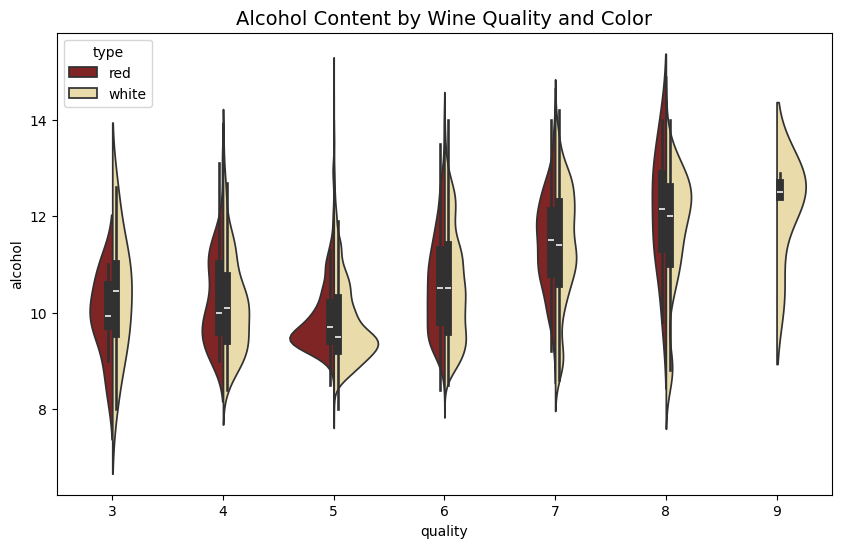

In [2]:
# 酒精與品質的分布 (小提琴圖)
# 這張圖可以看不同顏色、不同品質下，酒精濃度的分布情況。

plt.figure(figsize=(10, 6))
sns.violinplot(x='quality', y='alcohol', hue='type', data=df, split=True, palette={'red': '#8E1616', 'white': '#F4E0A1'})
plt.title('Alcohol Content by Wine Quality and Color', fontsize=14)
plt.show()

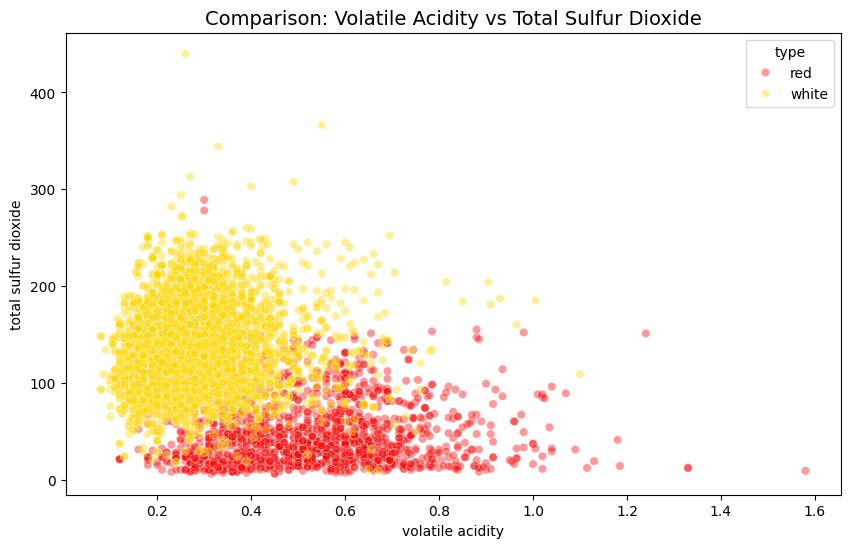

In [3]:
# 揮發性酸 vs. 總二氧化硫
# 這是紅、白酒差異最明顯的地方。

plt.figure(figsize=(10, 6))
sns.scatterplot(x='volatile acidity', y='total sulfur dioxide', hue='type', data=df, alpha=0.4, palette={'red': 'red', 'white': 'gold'})
plt.title('Comparison: Volatile Acidity vs Total Sulfur Dioxide', fontsize=14)
plt.show()

決策樹模型準確率 (Accuracy): 0.5342

分類報告 (Classification Report):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.20      0.02      0.03        57
           5       0.57      0.62      0.60       518
           6       0.53      0.62      0.57       738
           7       0.46      0.33      0.39       259
           8       0.00      0.00      0.00        43
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1625
   macro avg       0.25      0.23      0.23      1625
weighted avg       0.50      0.53      0.51      1625



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


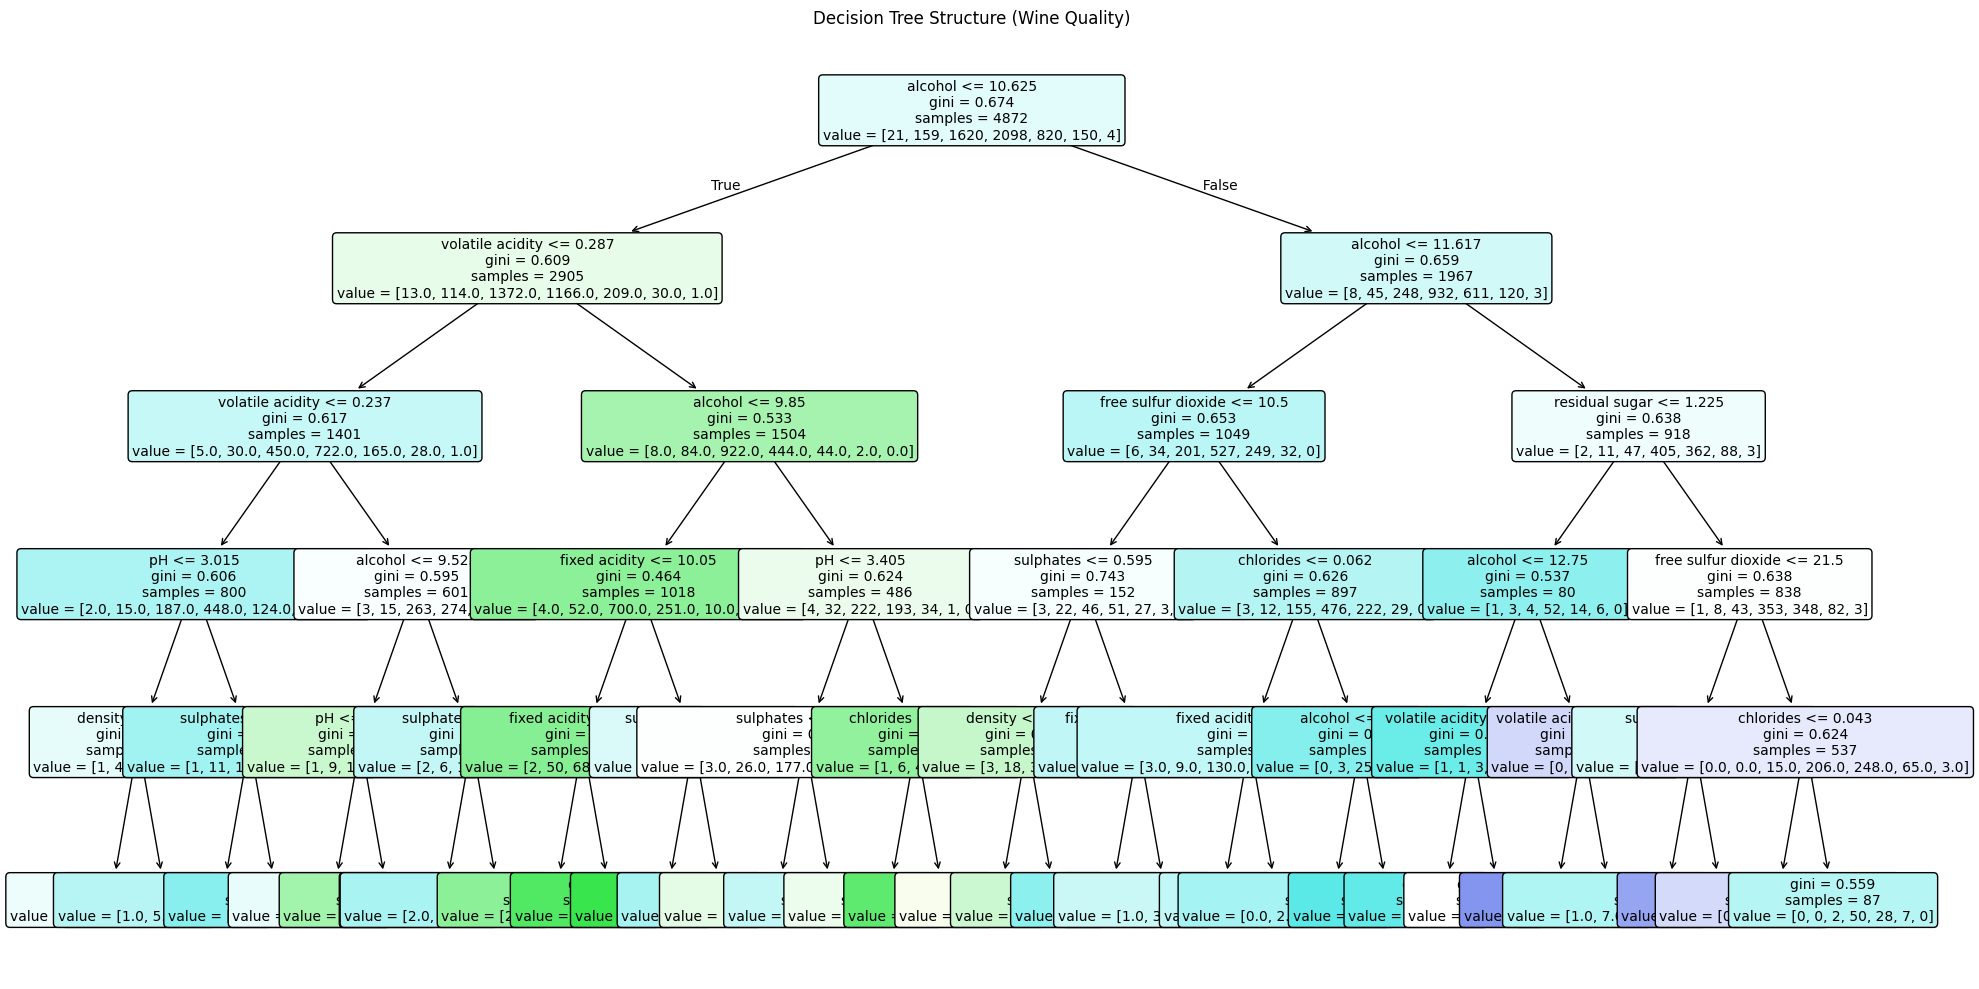

In [4]:
# 2. 數據標記與合併
red_wine['type'] = 1    # 紅酒標記為 1
white_wine['type'] = 0  # 白酒標記為 0
df_all = pd.concat([red_wine, white_wine], axis=0)

# 3. 特徵 (X) 與目標 (y)
# 目標：預測品質 (也可以改成預測紅白酒，但這裡先照你的專案預測品質)
X = df_all.drop('quality', axis=1)
y = df_all['quality']

# 4. 隨機拆分資料 75:25
# 設定 random_state=42 確保資料完全同一份
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 5. 決策樹模型 (Decision Tree)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 6. 預測與評估
y_pred = dt_model.predict(X_test)
print(f"決策樹模型準確率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\n分類報告 (Classification Report):")
print(classification_report(y_test, y_pred))

# 7. 視覺化決策樹 (簡報必備)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure (Wine Quality)")
plt.tight_layout()
plt.subplots_adjust
plt.show()

In [7]:
from sklearn.metrics import classification_report, accuracy_score

# 1. 讓模型預測測試集 (那 25% 的模擬考題)
y_pred = dt_model.predict(X_test)

# 2. 計算總分 (Accuracy)
acc = accuracy_score(y_test, y_pred)

# 3. 產出詳細成績單 (包含各項指標)
report = classification_report(y_test, y_pred)

print(f"得分：{acc:.4f}")
print("\n--- 詳細分科成績 (Classification Report) ---")
print(report)

得分：0.5342

--- 詳細分科成績 (Classification Report) ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.20      0.02      0.03        57
           5       0.57      0.62      0.60       518
           6       0.53      0.62      0.57       738
           7       0.46      0.33      0.39       259
           8       0.00      0.00      0.00        43
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1625
   macro avg       0.25      0.23      0.23      1625
weighted avg       0.50      0.53      0.51      1625



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
